# Chapter 2: Theoretical Foundations of Stochastic Chemical Kinetics
**Supplementary Code for Dissertation Figures 2.1 – 2.6**

This notebook generates all computational figures used in Chapter 2, bridging exact stochastic kinetics with continuous diffusion approximations. It covers:
* **Fig 2.1:** Convergence of exact stochastic simulation (SSA) to the deterministic ODE limit.
* **Fig 2.2:** Probabilistic analysis of the Lotka-Volterra model via the Chemical Master Equation.
* **Fig 2.3:** Microscopic wait-and-jump dynamics of the Gillespie algorithm.
* **Fig 2.4:** The Tau-Leaping approximation method.
* **Fig 2.5:** Sample realisations of a standard Wiener process (Brownian motion).
* **Fig 2.6:** The Central Limit Theorem and Gaussian approximation of Poisson noise.

*(Note: Figures 2.7 through 2.10 are theoretical diagrams rendered natively in LaTeX via TikZ and do not require Python execution).*

### Environment Setup & Module Imports
This cell configures the JAX environment for high-performance array operations and imports the core simulation package (`jsmfsb`). The `autoreload` extension ensures that any modifications made to the local `src/` modules are instantly reflected in this notebook.

In [ ]:
# Environment Setup & Module Imports
import sys
import os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import jsmfsb
import seaborn as sns
from scipy.stats import poisson, norm

# Route imports to the src folder
sys.path.append(os.path.abspath('..'))

# Enable autoreload for custom modules
%load_ext autoreload
%autoreload 2

from src.solvers import make_step_tau

# Academic Plotting
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

### Figure 2.1: Convergence of the SSA to the Deterministic Limit
This simulation demonstrates Kurtz's limit theorem using the Lotka-Volterra model. By scaling the system volume ($\Omega$), we observe the transition from highly stochastic dynamics (low molecule counts) to smooth, deterministic behaviour governed by ordinary differential equations (ODEs).

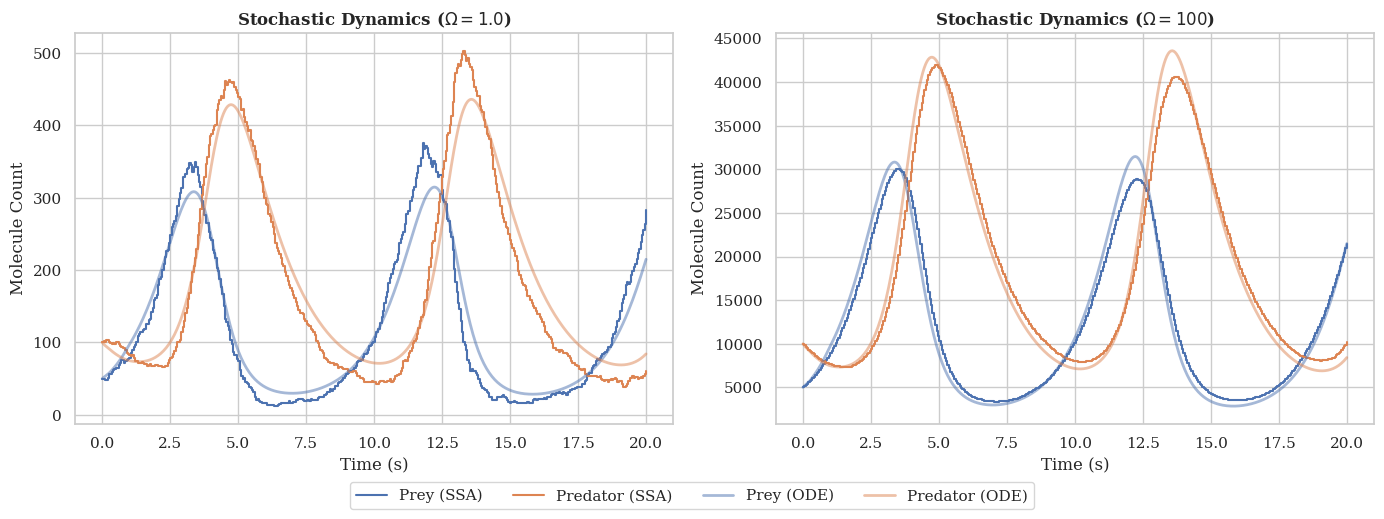

In [2]:
# Figure 2.1 - Convergence of the SSA to the Deterministic Limit (Lotka-Volterra)

def simulate_lv(omega, key):
    lv_sh = f"""
    @model:3.1.1=LotkaVolterra
    @compartments
     Cell
    @species
     Cell:Prey={int(50 * omega)}
     Cell:Predator={int(100 * omega)}
    @reactions
     @r=PreyReproduction
      Prey -> 2Prey
      1.0*Prey
     @r=PredatorPreyInteraction
      Prey+Predator -> 2Predator
      {0.005 / omega}*Prey*Predator
     @r=PredatorDeath
      Predator ->
      0.6*Predator
    """
    mod = jsmfsb.shorthand_to_spn(lv_sh)
    step_ssa = mod.step_gillespie()
    out_ssa = jsmfsb.sim_time_series(key, mod.m, 0, 20, 0.05, step_ssa)
    step_ode = mod.step_euler()
    out_ode = jsmfsb.sim_time_series(key, mod.m, 0, 20, 0.05, step_ode)
    return out_ssa, out_ode, mod.n

k0 = jax.random.key(42)
k1, k2 = jax.random.split(k0)

# FIXED: Volumes array now matches the plot titles
volumes = [1.0, 100] 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for i, omega in enumerate(volumes):
    key = k1 if i == 0 else k2
    data_ssa, data_ode, names = simulate_lv(omega, key)
    t = jnp.linspace(0, 20, data_ssa.shape[0])
    
    # SSA
    axes[i].step(t, data_ssa[:, 0], color='C0', label='Prey (SSA)', where='post')
    axes[i].step(t, data_ssa[:, 1], color='C1', label='Predator (SSA)', where='post')

    # ODE 
    axes[i].plot(t, data_ode[:, 0], color='C0', alpha=0.5, linewidth=2, label='Prey (ODE)')
    axes[i].plot(t, data_ode[:, 1], color='C1', alpha=0.5, linewidth=2, label='Predator (ODE)')

    if i == 0:
        axes[i].set_title(f"Stochastic Dynamics ($\\Omega = {volumes[0]}$)", fontweight='bold')
    else:
        axes[i].set_title(f"Stochastic Dynamics ($\\Omega = {volumes[1]}$)", fontweight='bold')
        
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Molecule Count")
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()

plt.savefig('../Dissertation_Figures/Fig2_1_LV_Convergence.png', dpi=300, bbox_inches='tight')

plt.show()

### Figure 2.2: Probabilistic Analysis of the Lotka-Volterra Model
An ensemble of 1,000 exact stochastic realisations. 
* **Top:** The "flow" of probability showing the stochastic trajectories.
* **Bottom:** The temporal evolution of the probability landscape, approximating the solution to the Chemical Master Equation (CME) via Kernel Density Estimation at distinct time points.

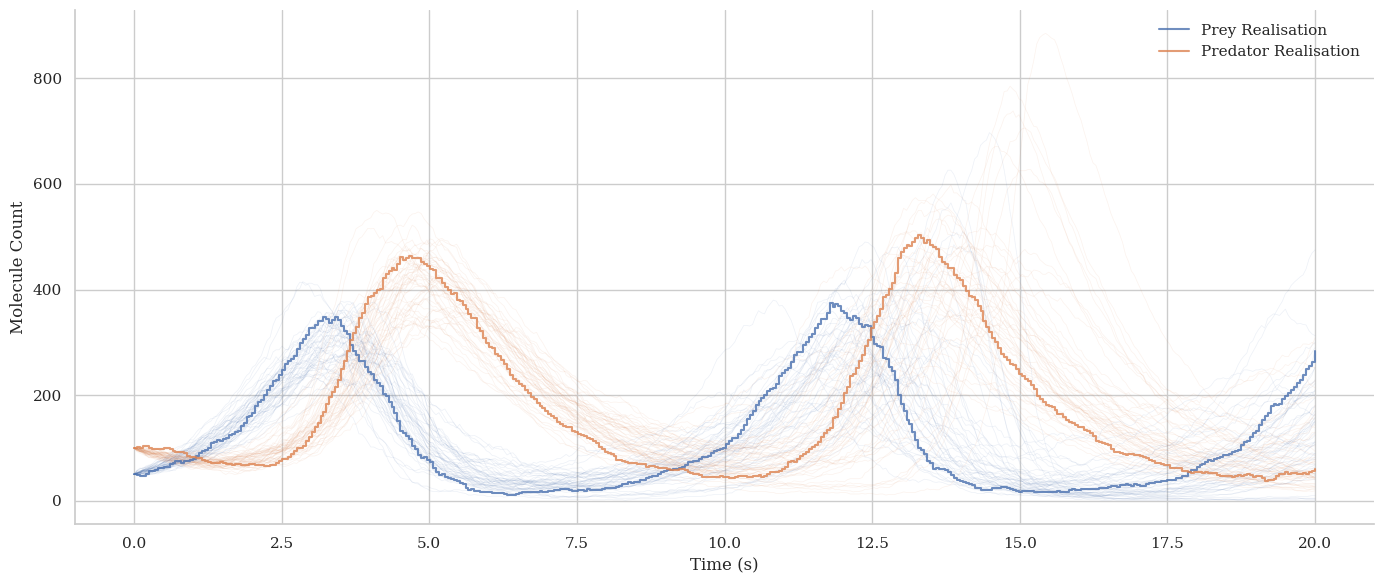

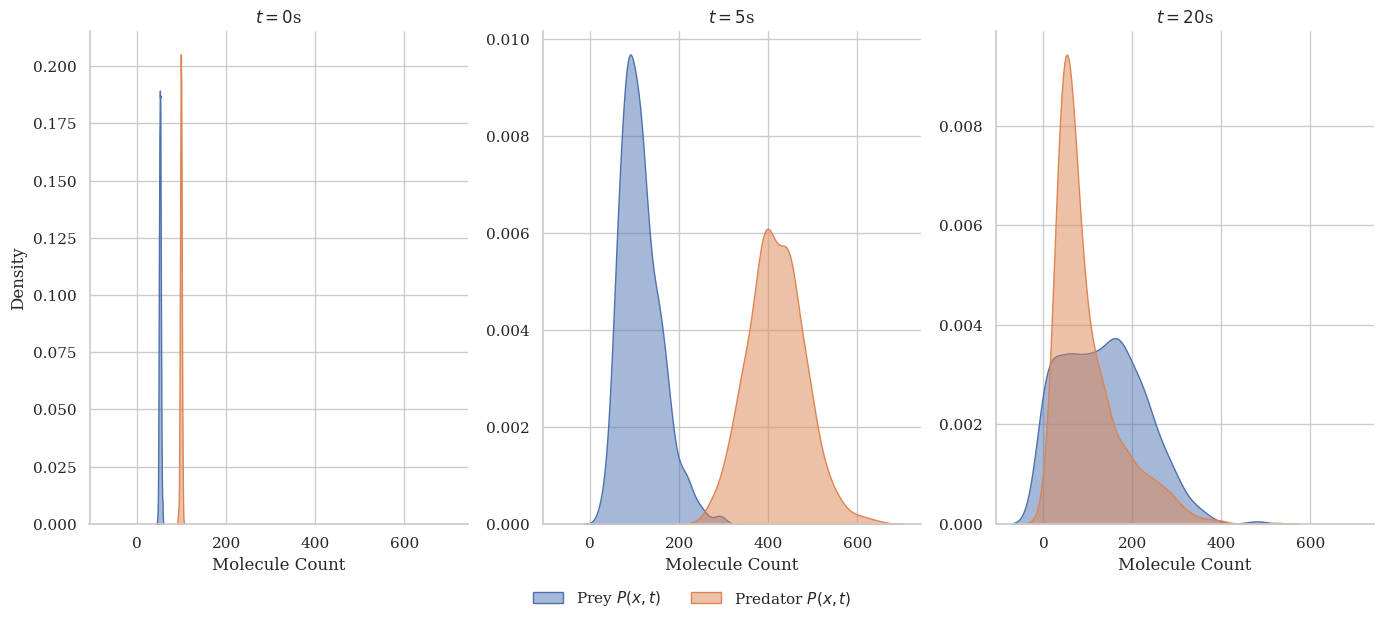

In [3]:
# Figure 2.2 - Probabilistic Analysis of the Lotka-Volterra Model (CME)

lvmod_sh = """
@model:3.1.1=LotkaVolterra
@compartments
 Cell
@species
 Cell:Prey=50
 Cell:Predator=100
@reactions
 @r=PreyReproduction
  Prey -> 2Prey
  1.0*Prey
 @r=PredatorPreyInteraction
  Prey+Predator -> 2Predator
  0.005*Prey*Predator
 @r=PredatorDeath
  Predator ->
  0.6*Predator
"""
lvmod = jsmfsb.shorthand_to_spn(lvmod_sh)
step_ssa = lvmod.step_gillespie()

def run_ensemble(num_sims, t_max, dt, key):
    def sim_one(k):
        return jsmfsb.sim_time_series(k, lvmod.m, 0, t_max, dt, step_ssa)
    
    keys = jax.random.split(key, num_sims)
    return jax.vmap(sim_one)(keys)

k0 = jax.random.key(42)
num_trajectories = 1000
t_max = 20
dt = 0.05

# ensemble shape: [1000, 401, 2] -> [Sims, Timepoints, Species]
ensemble = run_ensemble(num_trajectories, t_max, dt, k0)
times = jnp.linspace(0, t_max, ensemble.shape[1])

# --- Plot 1: Stochastic Trajectories ---
fig0, ax = plt.subplots(figsize=(14, 6))

# Probability Cloud (plot first 50 realisations)
for i in range(50):
    ax.plot(times, ensemble[i, :, 0], color='C0', alpha=0.1, linewidth=0.5)
    ax.plot(times, ensemble[i, :, 1], color='C1', alpha=0.1, linewidth=0.5)

# Highlight one realisation
ax.step(times, ensemble[0, :, 0], color='C0', label='Prey Realisation', alpha=0.8, where='post')
ax.step(times, ensemble[0, :, 1], color='C1', label='Predator Realisation', alpha=0.8, where='post')

ax.set_xlabel("Time (s)")
ax.set_ylabel("Molecule Count")
ax.legend(loc='upper right', frameon=False)
sns.despine(ax=ax)
fig0.tight_layout()

# Save Part A
fig0.savefig('../Dissertation_Figures/Fig2_2a_LV_Trajectories.png', dpi=300, bbox_inches='tight')

# --- Plot 2: Chemical Master Equation ---
fig1, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True)
snapshot_idxs = [1, 100, 400]

for i in range(3):
    prey_counts = ensemble[:, snapshot_idxs[i], 0]
    pred_counts = ensemble[:, snapshot_idxs[i], 1]
    t = int(times[snapshot_idxs[i]])
    
    sns.kdeplot(prey_counts, ax=axes[i], fill=True, color='C0', label='Prey $P(x, t)$', alpha=0.5)
    sns.kdeplot(pred_counts, ax=axes[i], fill=True, color='C1', label='Predator $P(x, t)$', alpha=0.5)

    axes[i].set_title(f"$t = {t}$s", fontsize=12)
    axes[i].set_xlabel("Molecule Count")
    
    if i > 0:
        axes[i].set_ylabel("")
    else:
        axes[i].set_ylabel("Density")

handles, labels = axes[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), frameon=False)

sns.despine(fig=fig1)
fig1.tight_layout()

# Save Part B
fig1.savefig('../Dissertation_Figures/Fig2_2b_LV_Distributions.png', dpi=300, bbox_inches='tight')

plt.show()

### Figure 2.3: Microscopic Wait-and-Jump Dynamics
This plot visualises a high-resolution, exact SSA realisation to highlight the core mechanics of the Gillespie algorithm: the exponentially distributed wait time to the next reaction ($\tau$) and the discrete state change vector ($\nu_j$).

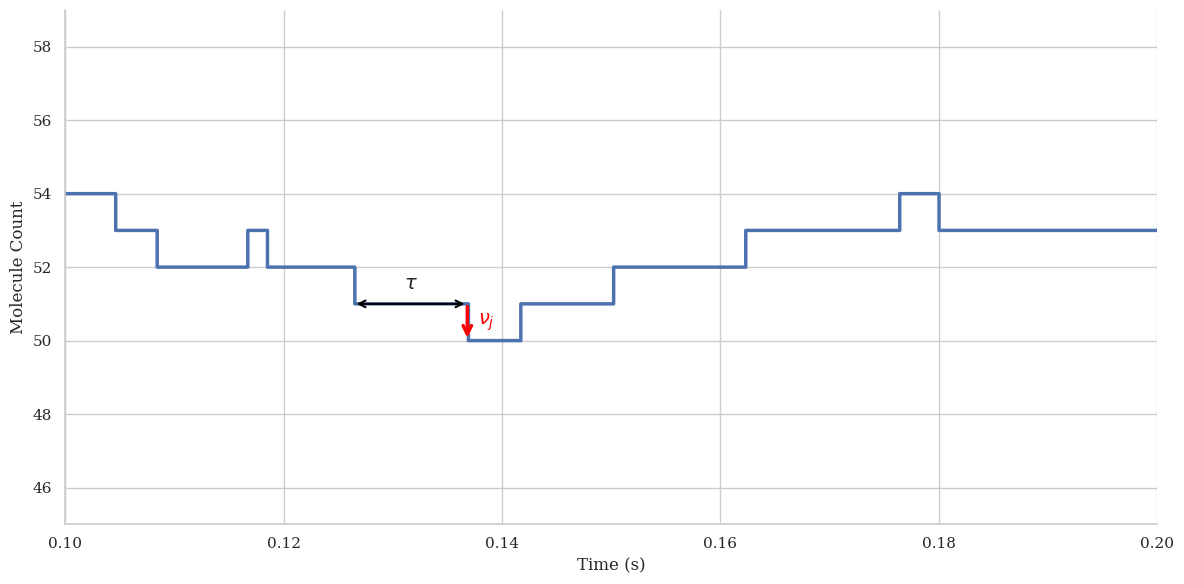

In [4]:
# Figure 2.3 - Microscopic Wait-and-Jump Dynamics

k_single = jax.random.key(123)
dt_fine = 0.0001  
t_max = 0.5   

# Uses lvmod from the previous cell
step_ssa = lvmod.step_gillespie()
raw_path = jsmfsb.sim_time_series(k_single, lvmod.m, 0, t_max, dt_fine, step_ssa)

times_fine = jnp.linspace(0, t_max, raw_path.shape[0])
prey_raw = raw_path[:, 0]

fig, ax = plt.subplots(figsize=(12, 6))

ax.step(times_fine, prey_raw, where='post', color='C0', linewidth=2.5, label='Prey Count $X(t)$')

ax.set_xlim(0.1, 0.2) 
ax.set_ylim(jnp.min(prey_raw[1000:2000])-5, jnp.max(prey_raw[1000:2000])+5)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Molecule Count", fontsize=12)

sns.despine()
plt.tight_layout()
jump_indices = np.where(np.diff(prey_raw) != 0)[0]

visible_jumps = [i for i in jump_indices if 0.12 < times_fine[i] < 0.18]

if len(visible_jumps) >= 2:
    idx_prev_jump = visible_jumps[0]
    idx_curr_jump = visible_jumps[1]
    
    t_start = times_fine[idx_prev_jump]
    t_end = times_fine[idx_curr_jump]
    y_level = prey_raw[idx_curr_jump]      
    y_next = prey_raw[idx_curr_jump + 1] 
    
    ax.annotate('', xy=(t_end, y_level), xytext=(t_start, y_level),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text((t_start + t_end)/2, y_level + 0.3, r'$\tau$', 
            ha='center', va='bottom', fontsize=14)

    ax.annotate('', xy=(t_end, y_next), xytext=(t_end, y_level),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5, mutation_scale=15))
    ax.text(t_end + 0.001, (y_level + y_next)/2, r'$\nu_j$', 
            color='red', va='center', fontweight='bold', fontsize=14)

plt.savefig('../Dissertation_Figures/Fig2_3_Wait_and_Jump.png', dpi=300, bbox_inches='tight')

plt.show()

### Figure 2.4: Comparative Dynamics of the Exact SSA and the Tau-Leaping Approximation
A comparison demonstrating how the Tau-Leaping method accelerates simulation times by approximating the exact wait-and-jump dynamics. Instead of simulating every individual reaction, it advances by a fixed time step ($\Delta t$) and samples the number of firings from a Poisson distribution.

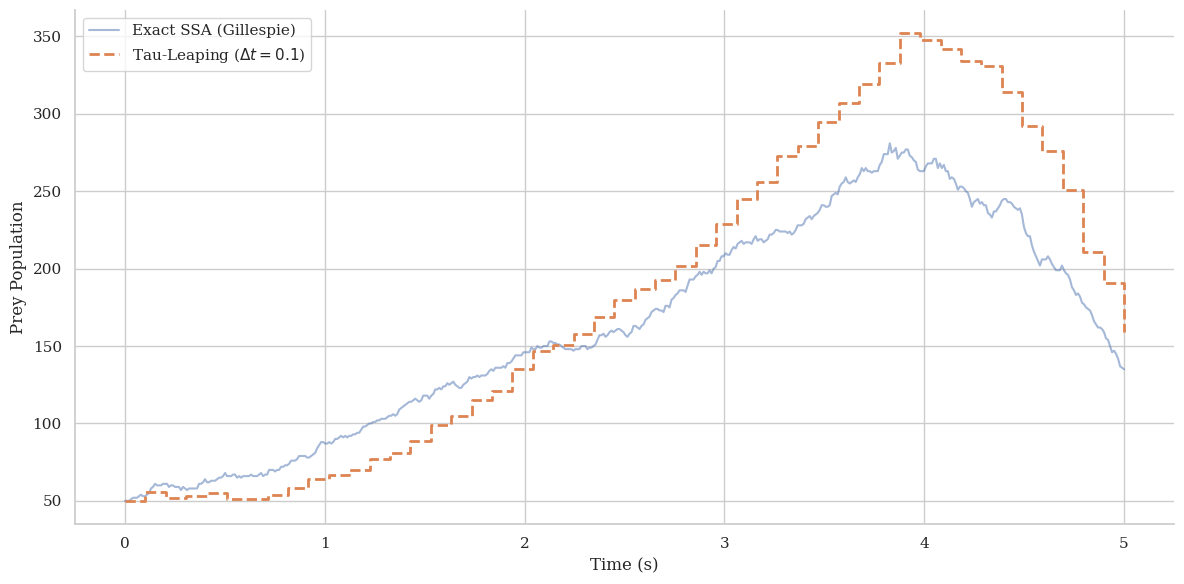

In [5]:
# Figure 2.4 - Exact SSA vs. Tau-Leaping

k_master = jax.random.key(88)
k1, k2 = jax.random.split(k_master)
t_end = 5

# 1. Exact SSA (Gillespie)
step_ssa = lvmod.step_gillespie()
path_ssa = jsmfsb.sim_time_series(k1, lvmod.m, 0, t_end, 0.01, step_ssa)

# 2. Tau-Leaping Approximation
# make_step_tau was imported from src.solvers
step_tau = make_step_tau(lvmod)
path_tau = jsmfsb.sim_time_series(k2, lvmod.m, 0, t_end, 0.1, step_tau)

# Plotting
plt.figure(figsize=(12, 6))
t_ssa = jnp.linspace(0, t_end, path_ssa.shape[0])
t_tau = jnp.linspace(0, t_end, path_tau.shape[0])

plt.plot(t_ssa, path_ssa[:, 0], label="Exact SSA (Gillespie)", alpha=0.5, color='C0')
plt.step(t_tau, path_tau[:, 0], where='post', label=r"Tau-Leaping ($\Delta t=0.1$)", 
         color='C1', linestyle='--', linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Prey Population")
plt.legend()
sns.despine()
plt.tight_layout()

plt.savefig('../Dissertation_Figures/Fig2_4_Tau_Leaping.png', dpi=300, bbox_inches='tight')

plt.show()

### Figure 2.5: Sample Realisations of a Standard Wiener Process
This block generates continuous stochastic trajectories using standard Brownian motion, which forms the foundation of the noise term in the Chemical Langevin Equation (CLE).

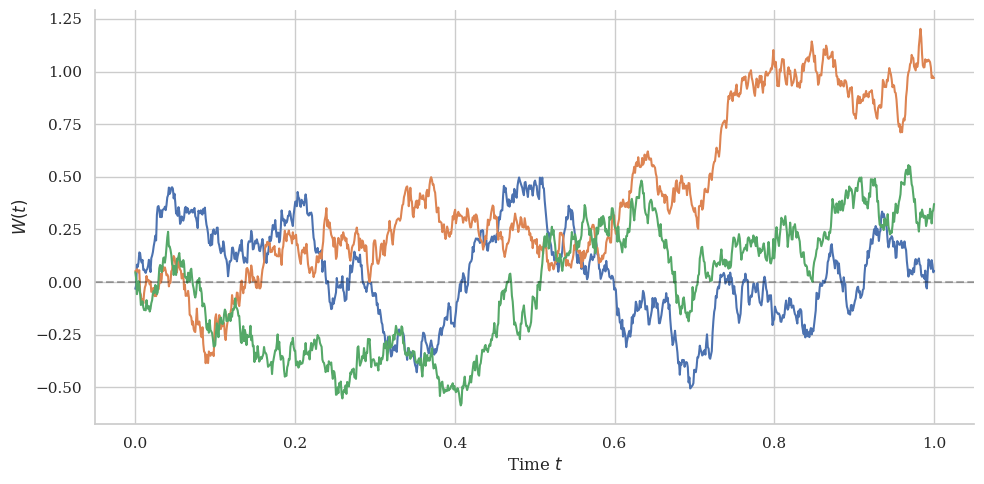

In [ ]:
# Figure 2.5 Execution

def plot_wiener_paths(num_paths=3, t_max=1.0, dt=0.001):
    key = jax.random.key(667)
    steps = int(t_max / dt)
    times = jnp.linspace(0, t_max, steps)
    keys = jax.random.split(key, num_paths)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for k in keys:
        # Scale random normal increments by sqrt(dt)
        increments = jax.random.normal(k, (steps,)) * jnp.sqrt(dt)
        path = jnp.cumsum(increments)
        ax.plot(times, path, linewidth=1.5)

    ax.set_xlabel("Time $t$")
    ax.set_ylabel("$W(t)$")
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    
    sns.despine(ax=ax)
    plt.tight_layout()
    
    plt.savefig('../Dissertation_Figures/Fig2_5_Wiener_Process.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_wiener_paths()

### Figure 2.6: The Central Limit Theorem and the Gaussian Approximation
This figure illustrates the mathematical justification for the continuous diffusion approximation. As the expected molecule count (the mean, $\lambda$) increases, the discrete Poisson distribution (representing exact reaction events) converges to a continuous Gaussian distribution, forming the basis of the Chemical Langevin Equation.

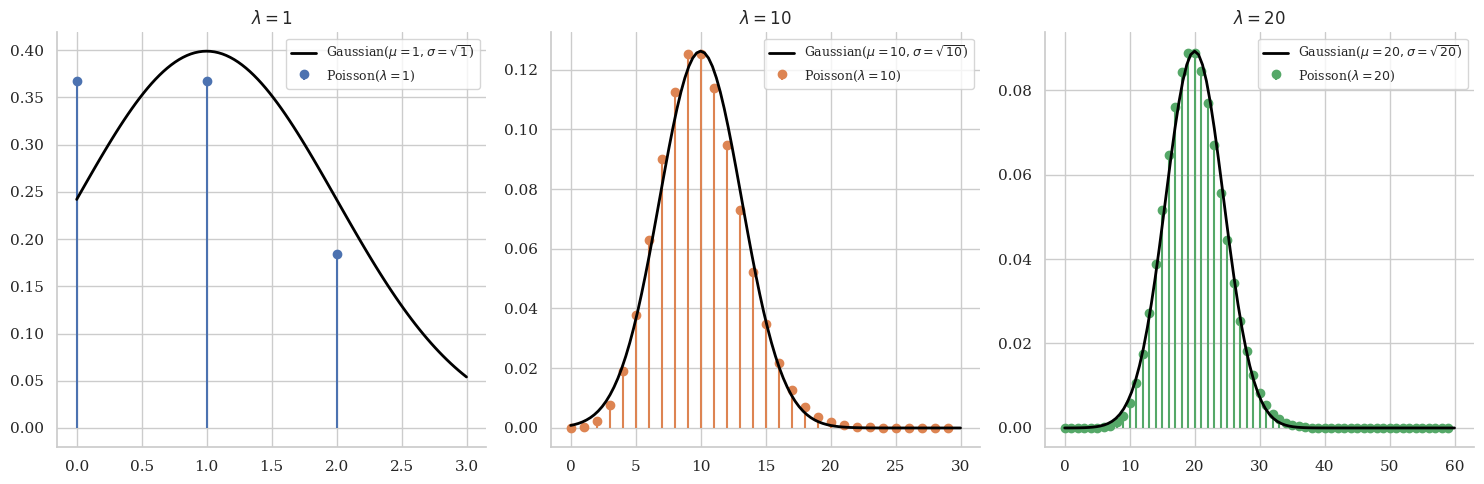

In [ ]:
# Figure 2.6 - The Central Limit Theorem

means = [1, 10, 20]
colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i, lam in enumerate(means):
    # Poisson (Discrete)
    x_pois = np.arange(0, lam * 3)
    axes[i].stem(x_pois, poisson.pmf(x_pois, lam), linefmt=colors[i], 
                 markerfmt=colors[i]+'o', basefmt=" ", label=f'Poisson($\\lambda={lam}$)')
    
    # Gaussian (Continuous Approximation)
    x_norm = np.linspace(0, lam * 3, 100)
    axes[i].plot(x_norm, norm.pdf(x_norm, lam, np.sqrt(lam)), 
                 color='black', lw=2, label=f'Gaussian($\\mu={lam}, \\sigma=\\sqrt{{{lam}}}$)')
    
    # Subplot titles 
    axes[i].set_title(f"$\\lambda = {lam}$", fontweight='bold')
    axes[i].legend(fontsize=9)
    sns.despine(ax=axes[i])

plt.tight_layout()

plt.savefig('../Dissertation_Figures/Fig2_6_CLT_Approximation.png', dpi=300, bbox_inches='tight')

plt.show()